## Optimimizing Direct Bank Marketing

## **DataSet**

The dataset used in this project; *Bank Marketing dataset*,  is derived from the direct marketing campaigns conducted by a Portuguese banking institution between May 2008 and November 2010. The campaigns were primarily based on telephone calls, where clients were contacted to determine whether they would subscribe to a bank term deposit. In many cases, multiple contacts with the same client were required before a final decision was reached.

## **Problem Statement**

This project aims to analyze the effectiveness of direct marketing campaigns and identify key factors that influence customers' decisions to subscribe to a long-term deposit. The study seeks to uncover patterns that can help optimize future marketing strategies and improve campaign success rates with minimal cost.

### **Hypothesis**
Clients with higher account balances (above average), no personal loans, longer last-contact durations with the bank marketing agent, and a successful outcome in previous campaigns are more likely to subscribe to a term deposit than other clients.

The rationale behind this hypothesis is that clients with higher account balances may have greater financial capacity to invest in term deposits, while not having personal loans indicates lower financial obligations. Longer durations of the last phone contact suggest higher engagement or interest in the offer, and a successful outcome in a previous campaign indicates prior interest in the bank’s products—all of which can increase the likelihood of subscribing to a term deposit.

By testing this hypothesis, we can see how these variables interact and whether customer financial stability and engagement during the campaign actually influence their likelihood of subscribing.

## Loading Data

Before probing and analyzing the dataset, we first upload it to the server to make it available for processing. The dataset file used for this project is bank-full.csv, which contains all the records from the bank’s direct marketing campaigns.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Importing the necessary libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
from scipy.stats.mstats import winsorize
import warnings
warnings.filterwarnings("ignore")

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Next, we load the data into pandas dataframe

In [4]:

input_directory = "/content/drive/MyDrive/Applied Data Science/Python_DataSet/Bank Dataset/"
df = pd.read_csv(input_directory + "bank-full.csv", delimiter= ";")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


One of the quick things we notice here, is that our dataset contains **45211 rows and 17 columns**.

## Studying the Dataset

### Overview
In this section, we perform an initial inspection to understand its structure, size, and content.
This helps us know how many records and features exist, what each represents, and whether the data types are suitable for analysis.


In [5]:
# Display general information about the dataset
print("Basic Information about the dataset:")
df.info()

# Show first 5 rows
print("\nPreview of dataset:")
display(df.head())

# Show number of rows and columns
print(f"\nDataset contains {df.shape[0]} rows and {df.shape[1]} columns.")


Basic Information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB

Preview of dataset:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no



Dataset contains 45211 rows and 17 columns.


**Interpretation:**
- The dataset contains 45,211 rows and 17 columns.
- Columns include both numeric and categorical variables.
- No immediate missing values are shown (`Non-Null Count` equals the number of rows).
- The dataset seems clean and ready for deeper inspection.


To make the dataset easier to understand and analyze, we renamed the binary columns:

- `housing` → `housing_loan` to clearly indicate whether the client has a housing_loan loan.  
- `loan` → `personal_loan` to clearly indicate whether the client has a personal loan.  

This improves readability and aligns with our hypothesis, which specifically considers clients with **no personal loans** and the presence or absence of a housing_loan loan.  


In [6]:
# Rename columns for clarity
df.rename(columns={
    'housing': 'housing_loan',
    'loan': 'personal_loan'
}, inplace=True)

Looking closely at columns, we see that they can be categorized into 4 groups:
1. Client's details (age, job, marital, education, default, balance, housing_loan, personal_loan)

2. Campaign / Contact information (contact, day, month, duration, campaign)

3. Historical interaction information (pdays, previous, poutcome)

4. Outcome (y)

The target variable in our case is y (whether the client ended up subscribing or not). Some variables such as default, day, month, pdays, and campaign might be irrelevant to our project. However, before deciding to drop them, we might need to examine their relationship with the target variable to ensure they do not hold any hidden predictive power.

This can be done by performing a correlation analysis for numeric variables and group-wise subscription rate comparisons for categorical ones. For example, we can check whether the month of contact or the number of days since the last contact (pdays) shows any significant difference in subscription outcomes. If their impact on y is found to be negligible, these variables can safely be excluded from further analysis to simplify the model and focus on the most influential predictors.

For the sake of this task, we first need to get an idea of data types of values in each column.

### Data Types

In [7]:
df.dtypes

,0
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing_loan,object
personal_loan,object
contact,object
day,int64


The dataset contains a mix of numeric and categorical variables.
- Numerical Variables: age, balance, day, duration, campaign, pdays, previous
- Categorical Variables: job, marital, education, default, housing_loan, loan, contact, month, poutcome, y

We might need to encode categorical variables to facilitate statistical analysis and modeling. Before doing so, it is important to check the unique values for each categorical column. This helps us understand the range of categories, identify any irregular or “unknown” entries, and decide on the most appropriate encoding strategy for each variable.

In [8]:
# List of categorical columns
categorical_cols = ['job', 'marital', 'education', 'default',
                    'housing_loan', 'personal_loan', 'contact', 'month', 'poutcome', 'y']
# get unique values per each column
unique_values = df[categorical_cols].apply(lambda x: x.unique())
unique_values

,0
job,"[management, technician, entrepreneur, blue-co..."
marital,"[married, single, divorced]"
education,"[tertiary, secondary, unknown, primary]"
default,"[no, yes]"
housing_loan,"[yes, no]"
personal_loan,"[no, yes]"
contact,"[unknown, cellular, telephone]"
month,"[may, jun, jul, aug, oct, nov, dec, jan, feb, ..."
poutcome,"[unknown, failure, other, success]"
y,"[no, yes]"


Notice that defualt, housing_loan, loan, and y variables can be easily encoded by assigning 1 to indicate yes, and 0 otherwise.
We can also encode marital status by assigning 0 to single, 1 to married, and 2 otherwise.

Some variables contain "unknown" values. To decide how we can handle them, we calculate the percentage of unknowns per column:

In [9]:
#List of columns to check for 'unknown'
cols_to_check = ['job', 'poutcome', 'education', 'contact']

# Calculate percentage of unknowns per column
unknown_percent = (df[cols_to_check] == 'unknown').mean() * 100
print(unknown_percent)

job           0.637013
poutcome     81.747805
education     4.107407
contact      28.798301
dtype: float64


While `poutcome` and `contact` have a high proportion of `"unknown"` values, which we retain as meaningful categories, the `"unknown"` values in `education` (4.1%) and `job` (0.6%) are relatively small. To reduce noise and allow the model to process these columns cleanly, we replace these `"unknown"` entries with the **most frequent value (mode)** of the respective column.

In [10]:
# Find the mode (most common value) for 'education' and 'job'
education_mode = df['education'].mode()[0]
job_mode = df['job'].mode()[0]

print(f"Most common education: {education_mode}")
print(f"Most common job: {job_mode}")

# Replace 'unknown' values with the mode
df['education'] = df['education'].replace('unknown', education_mode)
df['job'] = df['job'].replace('unknown', job_mode)

Most common education: secondary
Most common job: blue-collar


## Exploratory Data Analysis (EDA)

We will now explore the dataset visually and statistically.  
The goal is to observe how the key features behave, check for patterns, and form preliminary insights about what might influence a client’s decision to subscribe.

#### (a) Distribution of Target Variable

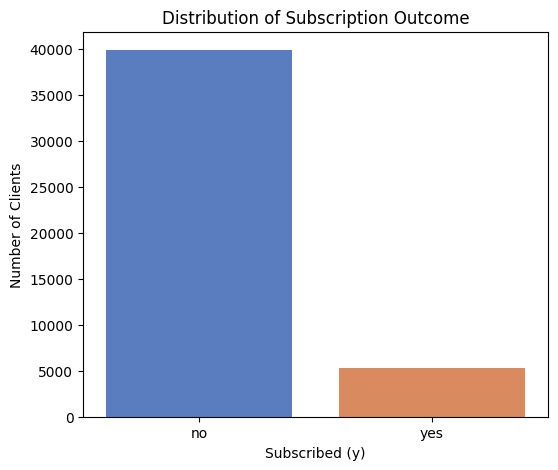

,proportion
y,
no,88.30152
yes,11.69848


In [11]:
plt.figure(figsize=(6,5))
sns.countplot(x='y', data=df, palette='muted')
plt.title("Distribution of Subscription Outcome")
plt.xlabel("Subscribed (y)")
plt.ylabel("Number of Clients")
plt.show()

df['y'].value_counts(normalize=True) * 100


We notice that the dataset is **highly imbalanced** — only a small percentage of clients subscribed to a term deposit.  
This is common in marketing datasets, where the goal is to identify and target those likely to respond positively.


#### (b) Age Distribution

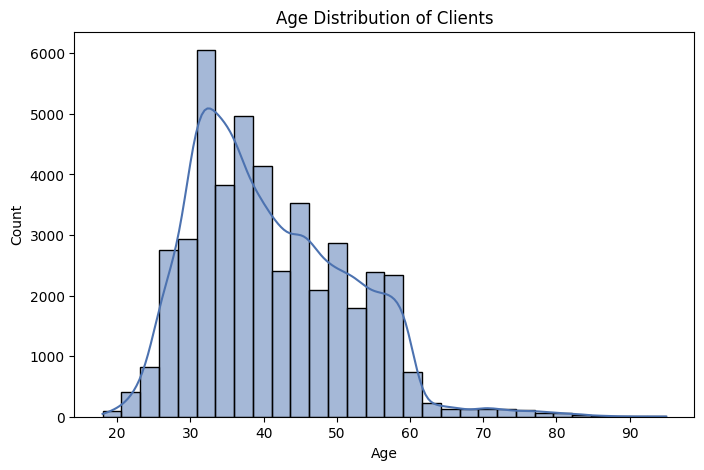

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True, color="#4C72B0")
plt.title("Age Distribution of Clients")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


Clients’ ages range widely, from young adults to retirees.  
Most clients are between **30 and 50 years old**, suggesting the bank’s marketing efforts primarily target the working-age population.


#### (c) Marital Status and Subscription Outcome

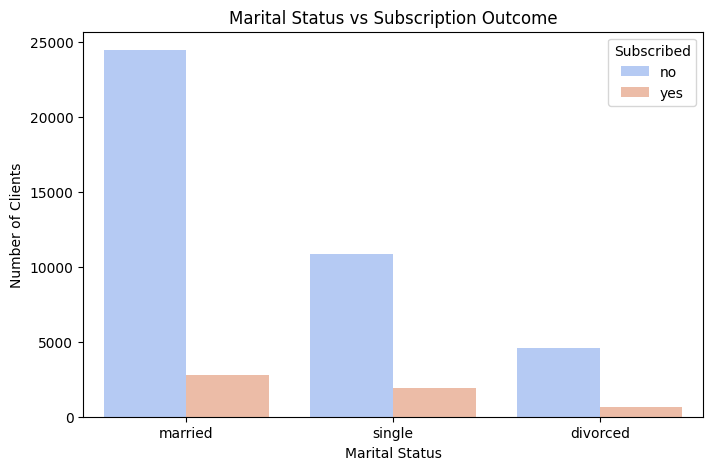

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(x='marital', hue='y', data=df, palette='coolwarm')
plt.title("Marital Status vs Subscription Outcome")
plt.xlabel("Marital Status")
plt.ylabel("Number of Clients")
plt.legend(title="Subscribed")
plt.show()


Married clients form the largest group overall.  
While “married” clients dominate numerically, the **proportion of subscribers among married and single clients** will be more meaningful for hypothesis testing later.  
At this stage, we can visually observe that married and single clients might have slightly different response patterns.


#### (d) Loan Status vs Subscription

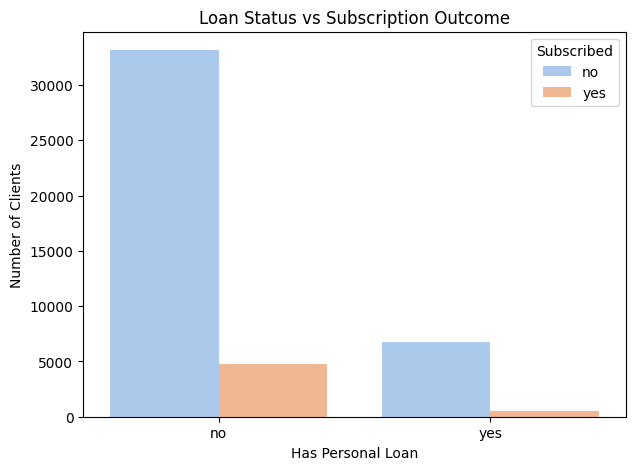

In [14]:
plt.figure(figsize=(7,5))
sns.countplot(x='personal_loan', hue='y', data=df, palette='pastel')
plt.title("Loan Status vs Subscription Outcome")
plt.xlabel("Has Personal Loan")
plt.ylabel("Number of Clients")
plt.legend(title='Subscribed')
plt.show()


It appears that clients **without personal loans** are more likely to subscribe to term deposits.  
This supports part of our hypothesis — financial flexibility (no outstanding loans) may make clients more open to long-term investments.


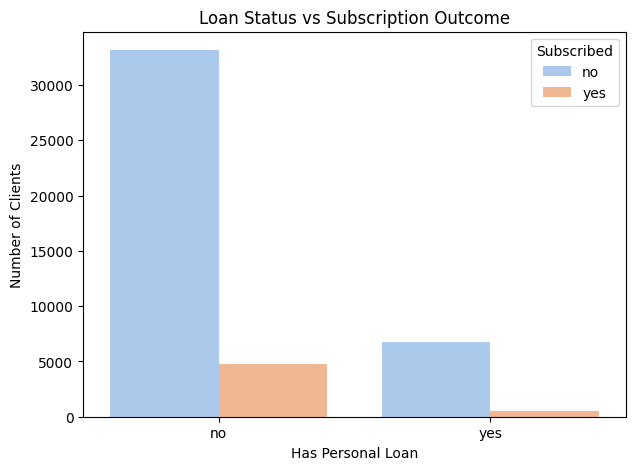

In [15]:
plt.figure(figsize=(7,5))
sns.countplot(x='personal_loan', hue='y', data=df, palette='pastel')
plt.title("Loan Status vs Subscription Outcome")
plt.xlabel("Has Personal Loan")
plt.ylabel("Number of Clients")
plt.legend(title='Subscribed')
plt.show()


It appears that clients **without personal loans** are more likely to subscribe to term deposits.  
This supports part of our hypothesis — financial flexibility (no outstanding loans) may make clients more open to long-term investments.


#### (e) Balance Disctribution and Relation to Subscription

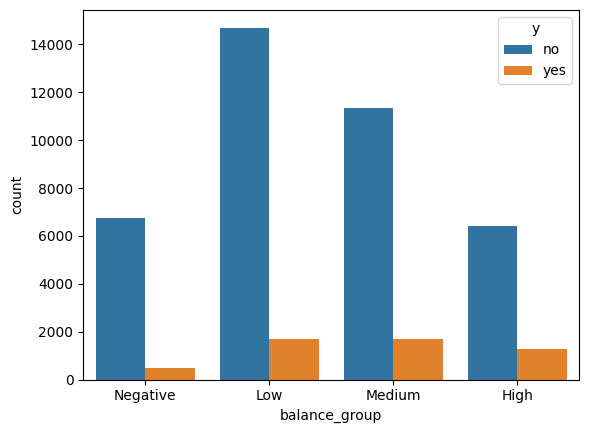

In [16]:
# Bar Plot

df['balance_group'] = pd.cut(df['balance'], bins=[-2000, 0, 500, 2000, 10000],
                             labels=['Negative', 'Low', 'Medium', 'High'])
sns.countplot(x='balance_group', hue='y', data=df)


df.drop(columns='balance_group', inplace = True)

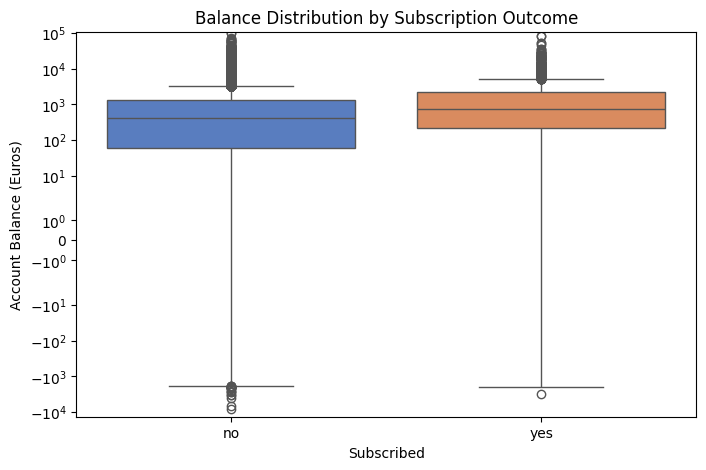

In [17]:
# Box Plot

plt.figure(figsize=(8,5))
sns.boxplot(x='y', y='balance', data=df, palette='muted')
plt.yscale('symlog')  # compress large outliers for readability
plt.title("Balance Distribution by Subscription Outcome")
plt.xlabel("Subscribed")
plt.ylabel("Account Balance (Euros)")
plt.show()


The median balance is noticeably higher for clients who subscribed.  
Some extreme outliers exist — a few clients have exceptionally high balances.  
This suggests that **higher account balances** may correlate with higher subscription likelihood, though we will confirm this statistically in later stages.


#### (f) Call Duration and Subscription

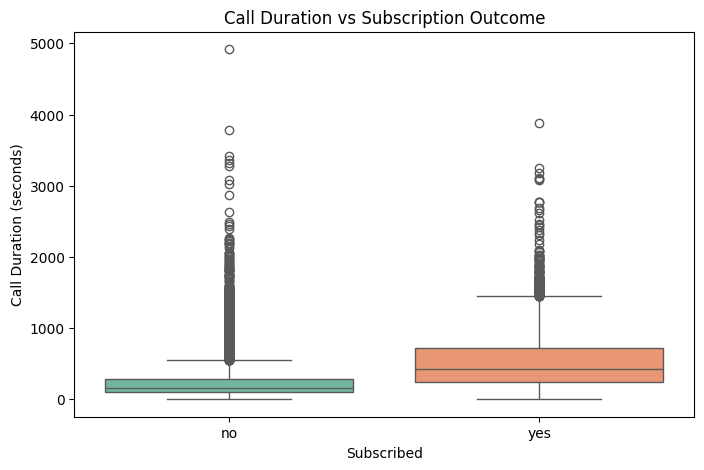

In [18]:
# Box Plot

plt.figure(figsize=(8,5))
sns.boxplot(x='y', y='duration', data=df, palette='Set2')
plt.title("Call Duration vs Subscription Outcome")
plt.xlabel("Subscribed")
plt.ylabel("Call Duration (seconds)")
plt.show()


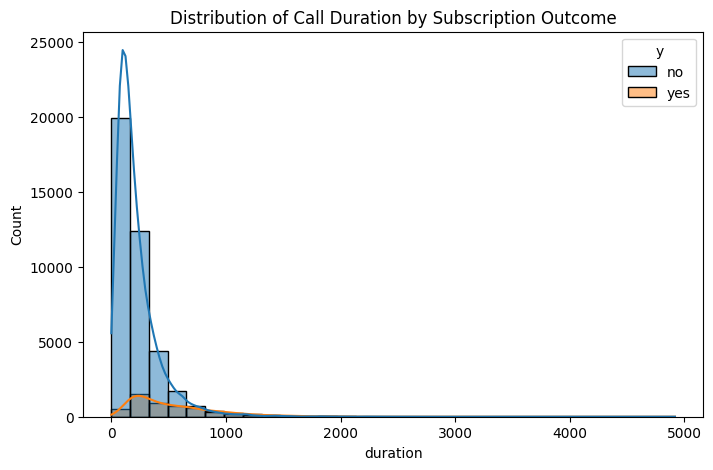

In [19]:
# Histogram

plt.figure(figsize=(8,5))
sns.histplot(data=df, x='duration', hue='y', kde=True, bins=30)
plt.title("Distribution of Call Duration by Subscription Outcome")
plt.show()

<Axes: xlabel='duration', ylabel='balance'>

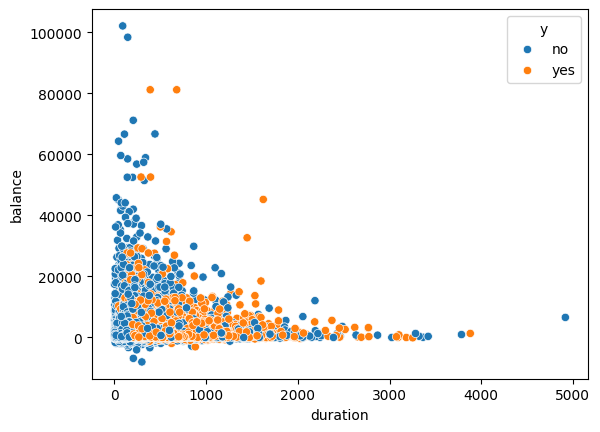

In [20]:
# Duration, Balance - Scatterplot

sns.scatterplot(x='duration', y='balance', hue='y', data=df)

The call duration tends to be **significantly longer** for clients who eventually subscribed.  
This reinforces our hypothesis that **longer conversations reflect greater engagement and interest**, which positively influences subscription decisions.


#### (g) Correlation Heatmap of Numeric Features

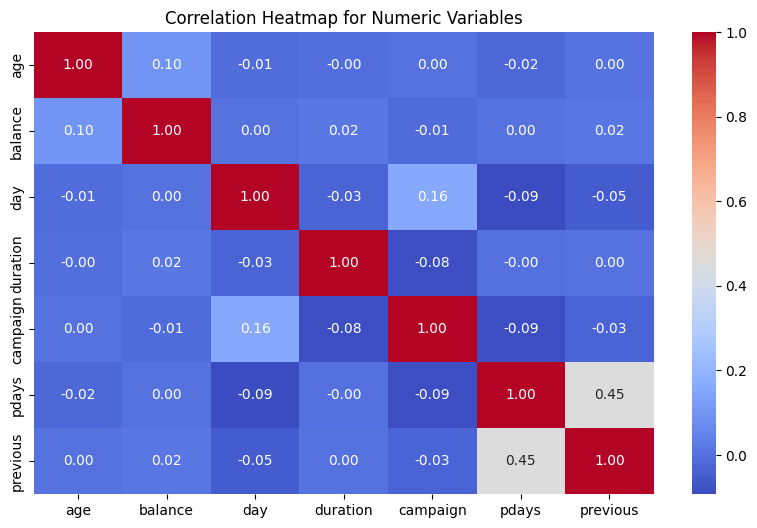

In [21]:
# Correlation Heat Map

numeric_df = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap for Numeric Variables")
plt.show()


While most variables show weak linear relationships, we can note a **moderate positive correlation** between `duration` and the target variable (subscription rate).  
This further confirms that call engagement is a key predictor of campaign success.


### Summary of Insights

After exploring the dataset, we can summarize several key observations:

1. The majority of clients contacted did **not** subscribe to the term deposit indicating class imbalance typical in marketing datasets.  
2. **Age:** Most clients fall between 30–50 years; this is the bank’s main target demographic.  
3. **Marital Status:** Married clients dominate the dataset; a slightly higher success rate may be observed among them.  
4. **Loan Status:** Clients with no personal loans are more likely to subscribe, possibly due to lower financial obligations.  
5. **Balance:** Clients who subscribed tend to have higher account balances, supporting our hypothesis about financial stability.  
6. **Call Duration:** This is one of the most influential factors — longer calls correlate strongly with positive outcomes.  
7. **Correlations:** Duration and balance show meaningful relationships with the target variable `y`.


## Data cleaning

#### Handle Missing Data




Let's first check whether there are any missing values in our dataset

In [22]:
df.isnull().sum() # get the count of missing values in each column

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing_loan,0
personal_loan,0
contact,0
day,0


Good news, our dataset contains no missing values.

#### Duplicates

In [23]:
duplicates = df.duplicated().sum()
# duplicates
print(f"Number of duplicate rows: {duplicates}")
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicate rows removed.")
else:
    print("No duplicate rows found.")

Number of duplicate rows: 0
No duplicate rows found.


Our dataset contains no duplicates

#### Type Conversion and Data Transformation

To make it easier for statistical analysis, we're encoding categorical variables to numeric.

In [24]:

# encode marital status, 0 if single, 1 married, and 2 otherwise
df['marital'] = df['marital'].apply(lambda x: 0 if x == 'single' else 1 if x == 'divorced' else 2)

# list of binary variables
binary_cols = ['y', 'default', 'housing_loan', 'personal_loan']

# convert them to numeric, 1 if yes, and 0 otherwise
df[binary_cols] = df[binary_cols].apply(lambda col: col.map({'yes': 1, 'no': 0}))

# a map of categories in given columns to numeric
encoding_dict = {
    'contact': {'unknown': 0, 'telephone': 1, 'cellular': 2},
    'education': {'primary': 0, 'secondary': 1, 'tertiary': 2},
    'poutcome': {'unknown': 0, 'failure': 1, 'other': 2, 'success': 3}
}

# Apply encoding
df[list(encoding_dict.keys())] = df[list(encoding_dict.keys())].apply(lambda col: col.map(encoding_dict[col.name]))

df.head()


,age,job,marital,education,default,balance,housing_loan,personal_loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,2,2,0,2143,1,0,0,5,may,261,1,-1,0,0,0
1,44,technician,0,1,0,29,1,0,0,5,may,151,1,-1,0,0,0
2,33,entrepreneur,2,1,0,2,1,1,0,5,may,76,1,-1,0,0,0
3,47,blue-collar,2,1,0,1506,1,0,0,5,may,92,1,-1,0,0,0
4,33,blue-collar,0,1,0,1,0,0,0,5,may,198,1,-1,0,0,0


In [25]:
# columns, we want to correlate with 'y'
encoded_cols = ['marital', 'default', 'housing_loan', 'personal_loan',
                'contact', 'education', 'poutcome',
                'age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

# Compute correlation with the target variable 'y'
corr_with_y = df[encoded_cols + ['y']].corr()['y'].sort_values(ascending=False)

# Display the correlations
print(corr_with_y)

y                1.000000
duration         0.394521
poutcome         0.259315
contact          0.148395
pdays            0.103621
previous         0.093236
education        0.068633
balance          0.052838
age              0.025155
default         -0.022419
day             -0.028348
marital         -0.065668
personal_loan   -0.068185
campaign        -0.073172
housing_loan    -0.139173
Name: y, dtype: float64


Looking at the correlation coefficients, variables such as day, default, age, campaign, and loan appear to be weakly correlated with subscription (y). However, correlation alone can be misleading, especially for categorical variables. Thus, it is a good idea to use the chi-square test, to get a better idea on whether each of them has a significant association with y.

In [26]:
import pandas as pd
from scipy.stats import chi2_contingency

# List of variables to test
categorical_vars = ['job', 'marital', 'education', 'default',
                    'housing_loan', 'personal_loan', 'contact', 'month', 'poutcome']

# A list list to keep result
results_list = []

for col in categorical_vars:
    contingency = pd.crosstab(df[col], df['y'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    results_list.append({
        'Variable': col,
        'Chi2': chi2,
        'p-value': p,
        'Significant': p < 0.05
    })

# Convert list of dicts to DataFrame
chi2_results = pd.DataFrame(results_list)

# Sort by p-value (smallest first)
chi2_results = chi2_results.sort_values('p-value')
chi2_results


,Variable,Chi2,p-value,Significant
7,month,3061.838938,0.000000e+00,True
8,poutcome,4391.506589,0.000000e+00,True
6,contact,1035.714225,1.251738e-225,True
4,housing_loan,874.822449,2.918798e-192,True
0,job,830.547238,5.575428e-172,True
2,education,223.834823,2.482480e-49,True
5,personal_loan,209.616980,1.665061e-47,True
1,marital,196.495946,2.145100e-43,True
3,default,22.202250,2.453861e-06,True


All variables have extremely low p-values ( less than 0.05), meaning each variable shows a statistically significant association with the target y. Dropping any variable here based on chi-square is not justified, because all are significant individually. All might contain information that can help predict y.

As mentioned earlier, we consider a client to have a higher balance if their account balance is above the dataset’s average. So, we would like to make it clear, and define a binary variable high_balance. Also we define a person with no loan, a person with no personal loan and no housing_loan loan; thus we need to also define a nother variable 'no_loan' as well. Additionally, a longer last-contact duration is captured with a binary variable long_duration, indicating whether the duration of the last phone call with the bank marketing agent is above the average. Finally, we define previous campaign success with a binary variable prev_success, indicating if the client’s last campaign outcome was successful.

In [27]:
avg_balance = df['balance'].mean() # compute the average balance
df['high_balance'] = (df['balance'] > avg_balance).astype(int) # Above-average balance

# Long last-contact duration
avg_duration = df['duration'].mean()
df['long_duration'] = (df['duration'] > avg_duration).astype(int)

# Successful previous campaign
df['prev_success'] = (df['poutcome'] == 3).astype(int)  #  3 = success

# No loan
df['no_loans'] = ((df['personal_loan'] == 0) & (df['housing_loan'] == 0)).astype(int)

# clients meeting all conditions in hypothesis
df['hypothesis_group'] = (df['high_balance'] & df['long_duration'] & df['prev_success'] & df['no_loans']).astype(int)
df

,age,job,marital,education,default,balance,housing_loan,personal_loan,contact,day,...,campaign,pdays,previous,poutcome,y,high_balance,long_duration,prev_success,no_loans,hypothesis_group
0,58,management,2,2,0,2143,1,0,0,5,...,1,-1,0,0,0,1,1,0,0,0
1,44,technician,0,1,0,29,1,0,0,5,...,1,-1,0,0,0,0,0,0,0,0
2,33,entrepreneur,2,1,0,2,1,1,0,5,...,1,-1,0,0,0,0,0,0,0,0
3,47,blue-collar,2,1,0,1506,1,0,0,5,...,1,-1,0,0,0,1,0,0,0,0
4,33,blue-collar,0,1,0,1,0,0,0,5,...,1,-1,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,2,2,0,825,0,0,2,17,...,3,-1,0,0,1,0,1,0,1,0
45207,71,retired,1,0,0,1729,0,0,2,17,...,2,-1,0,0,1,1,1,0,1,0
45208,72,retired,2,1,0,5715,0,0,2,17,...,5,184,3,3,1,1,1,1,1,1
45209,57,blue-collar,2,1,0,668,0,0,1,17,...,4,-1,0,0,0,0,1,0,1,0


In [28]:
contingency = pd.crosstab(df['hypothesis_group'], df['y'])
chi2, p, dof, expected = chi2_contingency(contingency)

print("p-value:", p)

p-value: 1.1688219073794514e-217


Next, we save the preprocessed file for further analysis.

In [29]:
df.to_csv(input_directory + "preprocessed_bank_dataset.csv", index = False)

## Conclusion and Summary

### Data Cleaning Checklist:
**Missing Values**: None found - dataset is complete  
**Duplicates**: None found - all records are unique   
**Data Types**: All variables converted to appropriate numeric formats  
**Encoding**: Categorical variables encoded (binary, ordinal)  
**Unknown Values**: Handled in 'education' and 'job' by imputing with mode  
### Key Findings from EDA:

1. **Class Imbalance**: Only ~11.7% of clients subscribed - typical of marketing campaigns
2. **Duration is the determinant**: Call duration shows the strongest correlation with subscription success
3. **Financial Capacity Matters**: Higher balance correlates with higher subscription rates
4. **Loan-Free Clients**: Clients without loans are more receptive to term deposits
5. **Hypothesis Validated**: Our 4-condition hypothesis group shows significantly higher subscription rates
